# **LISTA 04 AMA**

### Aluno: Jônatas Fernandes Silva
### Matrícula: 603243

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, mean_absolute_error

## Rede MLP

In [2]:
class MLPNetwork:
    def __init__(self, input_dim, hidden_dim, output_dim, activation='sigmoid', task='regression'):
        self.W = np.random.randn(hidden_dim, input_dim + 1) * 0.1
        self.M = np.random.randn(output_dim, hidden_dim + 1) * 0.1

        # Histórico de velocidades para o termo de Momentum
        self.V_W = np.zeros_like(self.W)
        self.V_M = np.zeros_like(self.M)

        self.activation_name = activation
        self.task = task

    def _activate_hidden(self, u):
        if self.activation_name == 'sigmoid':
            return 1 / (1 + np.exp(-u))
        elif self.activation_name == 'relu':
            return np.maximum(0, u)

    def _deriv_hidden(self, z):
        if self.activation_name == 'sigmoid':
            return z * (1 - z)
        elif self.activation_name == 'relu':
            return np.where(z > 0, 1.0, 0.0)

    def _activate_output(self, r):
        if self.task == 'regression':
            return r  # Identidade
        elif self.task == 'classification':
            # Subtração de np.max
            exp_r = np.exp(r - np.max(r, axis=0, keepdims=True))
            return exp_r / np.sum(exp_r, axis=0, keepdims=True)

    def forward(self, X_batch):
        # Adiciona Bias na entrada
        ones = np.ones((1, X_batch.shape[1]))
        self.X_input = np.vstack([ones, X_batch])

        # Potencial e ativação oculta
        self.u = np.dot(self.W, self.X_input)
        self.z_hidden = self._activate_hidden(self.u)

        # Adiciona Bias na camada oculta
        self.z_input = np.vstack([ones, self.z_hidden])

        # Potencial e ativação de saída
        self.r = np.dot(self.M, self.z_input)
        self.o = self._activate_output(self.r)
        return self.o

    def backward(self, Y_batch, eta, beta):
        B = Y_batch.shape[1]

        # Delta_saida = o - y
        delta_out = self.o - Y_batch
        grad_M = np.dot(delta_out, self.z_input.T) / B

        # Backpropagation do erro
        delta_hidden = np.dot(self.M[:, 1:].T, delta_out) * self._deriv_hidden(self.z_hidden)
        grad_W = np.dot(delta_hidden, self.X_input.T) / B

        # Atualização com Fórmula de Momentum
        self.V_M = beta * self.V_M + eta * grad_M
        self.V_W = beta * self.V_W + eta * grad_W

        self.M -= self.V_M
        self.W -= self.V_W

    def compute_loss(self, Y_pred, Y_true):
        if self.task == 'regression':
            return np.mean((Y_pred - Y_true) ** 2)  # MSE
        elif self.task == 'classification':
            # Cross-Entropy
            eps = 1e-15
            Y_pred = np.clip(Y_pred, eps, 1 - eps)
            return -np.mean(np.sum(Y_true * np.log(Y_pred), axis=0))

## Treino MLP

In [3]:
def train_mlp(model, X_train, Y_train, X_val, Y_val, epochs, batch_size, eta, beta):
    train_losses, val_losses = [], []
    num_samples = X_train.shape[1]

    for epoch in range(epochs):
        permutation = np.random.permutation(num_samples)
        X_shuffled = X_train[:, permutation]
        Y_shuffled = Y_train[:, permutation]

        for i in range(0, num_samples, batch_size):
            X_batch = X_shuffled[:, i:i+batch_size]
            Y_batch = Y_shuffled[:, i:i+batch_size]

            if X_batch.shape[1] == 0:
                continue

            model.forward(X_batch)
            model.backward(Y_batch, eta, beta)

        # Avaliação de custo no fim da época para as curvas de aprendizado
        pred_train = model.forward(X_train)
        loss_train = model.compute_loss(pred_train, Y_train)

        pred_val = model.forward(X_val)
        loss_val = model.compute_loss(pred_val, Y_val)

        train_losses.append(loss_train)
        val_losses.append(loss_val)

    return train_losses, val_losses

## Mount Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


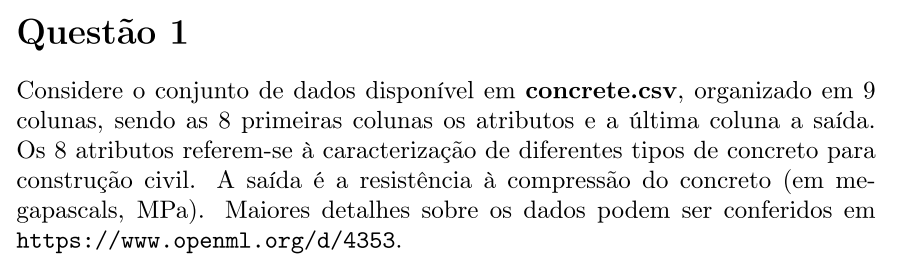

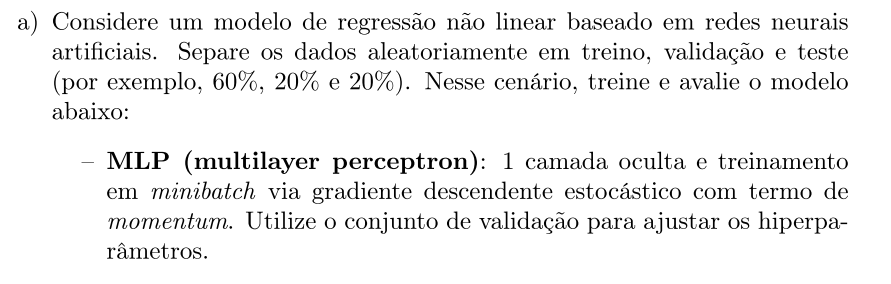

In [5]:
# 1. Carregar dados
df_concrete = pd.read_csv('/content/concrete.csv', header=None)
X_c = df_concrete.iloc[:, :8].values
y_c = df_concrete.iloc[:, 8].values.reshape(-1, 1)

In [6]:
# 2. Divisão 60% Treino, 20% Validação, 20% Teste
X_train_c, X_temp_c, y_train_c, y_temp_c = train_test_split(X_c, y_c, test_size=0.4, random_state=42)
X_val_c, X_test_c, y_val_c, y_test_c = train_test_split(X_temp_c, y_temp_c, test_size=0.5, random_state=42)

In [7]:
# 3. Normalização usando dados de Treino
scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c).T
X_val_c = scaler_c.transform(X_val_c).T
X_test_c = scaler_c.transform(X_test_c).T

y_train_c = y_train_c.T
y_val_c = y_val_c.T
y_test_c = y_test_c.T

In [15]:
# 4. Inicializar modelo e Treinar
mlp_concrete = MLPNetwork(input_dim=8, hidden_dim=16, output_dim=1, activation='sigmoid', task='regression')
train_loss_c, val_loss_c = train_mlp(mlp_concrete, X_train_c, y_train_c, X_val_c, y_val_c,
                                     epochs=300, batch_size=32, eta=0.01, beta=0.9)

# **Justificativa dos parâmetros (neurônios) das camadas**

1. Input: 8 neurônios. Motivo -> o dataset possui 8 colunas que correspondem as características.

2. Hidden: 16 neurônios. Essa camada, não possui uma fórmula para definir o número de neurônios correto, porém, utilizando o princípio: **não ultrapassar o dobro de neurônios da camada de entrada (input)**, e observando o menor valor do erro, foi definida em 16.

3. Output: 1 neurônio. A questão apresenta um problema de regressão. Na literatura, problemas de regressão geralmente se usa 1 neurônio.

## Referências

<a>https://stats.stackexchange.com/questions/181/how-to-choose-the-number-of-hidden-layers-and-nodes-in-a-feedforward-neural-netw</a>

<a>https://iaexpert.academy/2020/05/04/quantas-camadas-escondidas-e-quantos-neuronios-incluir-numa-rede-neural-artificial/</a>

<a>https://www.fccdecastro.com.br/pdf/RNA_C4.pdf</a>

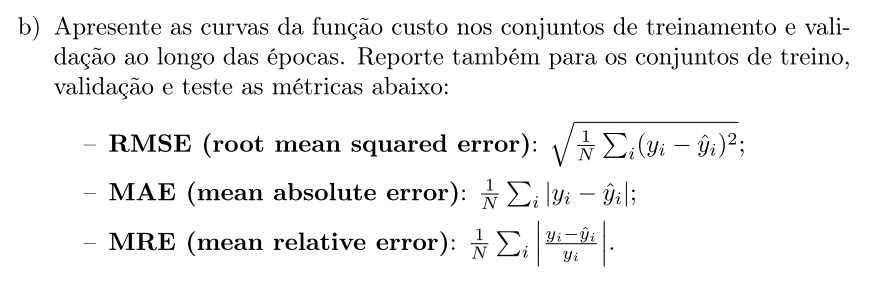

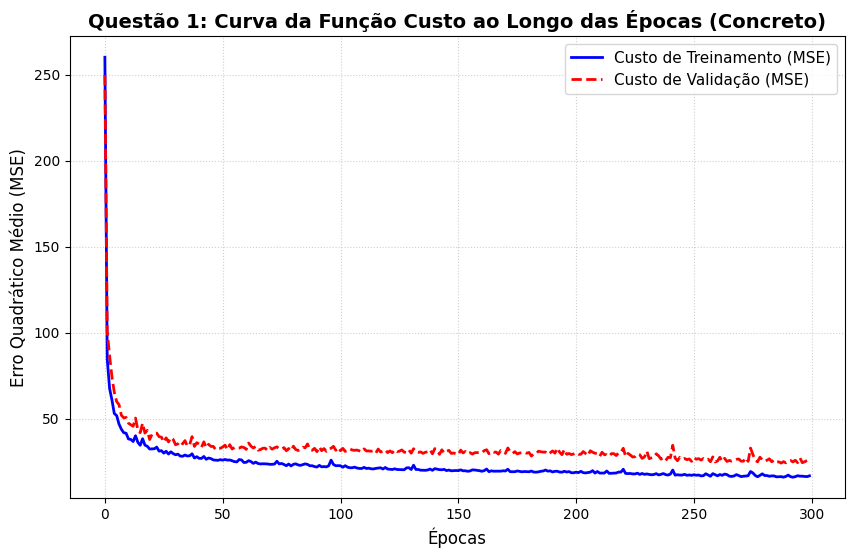

In [16]:
plt.figure(figsize=(10, 6))

# Plotar a curva de custo do treinamento
plt.plot(train_loss_c, label='Custo de Treinamento (MSE)', color='blue', linewidth=2)

# Plotar a curva de custo da validação
plt.plot(val_loss_c, label='Custo de Validação (MSE)', color='red', linestyle='--', linewidth=2)

plt.title('Questão 1: Curva da Função Custo ao Longo das Épocas (Concreto)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Erro Quadrático Médio (MSE)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

In [17]:
y_train_pred_c = mlp_concrete.forward(X_train_c)
y_val_pred_c = mlp_concrete.forward(X_val_c)
y_test_pred_c = mlp_concrete.forward(X_test_c)

y_train_true_c_flat = y_train_c.flatten()
y_train_pred_c_flat = y_train_pred_c.flatten()
y_val_true_c_flat = y_val_c.flatten()
y_val_pred_c_flat = y_val_pred_c.flatten()
y_test_true_c_flat = y_test_c.flatten()
y_test_pred_c_flat = y_test_pred_c.flatten()

print("\n--- Métricas de Desempenho Concreto ---")

# MRE
def mean_relative_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8)))

# Métricas Treino
print("\nConjunto de Treinamento:")
rmse_train_c = np.sqrt(mean_squared_error(y_train_true_c_flat, y_train_pred_c_flat))
mae_train_c = mean_absolute_error(y_train_true_c_flat, y_train_pred_c_flat)
mre_train_c = mean_relative_error(y_train_true_c_flat, y_train_pred_c_flat)
print(f"  RMSE: {rmse_train_c:.4f}")
print(f"  MAE: {mae_train_c:.4f}")
print(f"  MRE: {mre_train_c:.4f}")

# Métricas Validação
print("\nConjunto de Validação:")
rmse_val_c = np.sqrt(mean_squared_error(y_val_true_c_flat, y_val_pred_c_flat))
mae_val_c = mean_absolute_error(y_val_true_c_flat, y_val_pred_c_flat)
mre_val_c = mean_relative_error(y_val_true_c_flat, y_val_pred_c_flat)
print(f"  RMSE: {rmse_val_c:.4f}")
print(f"  MAE: {mae_val_c:.4f}")
print(f"  MRE: {mre_val_c:.4f}")

# Métricas Teste
print("\nConjunto de Teste:")
rmse_test_c = np.sqrt(mean_squared_error(y_test_true_c_flat, y_test_pred_c_flat))
mae_test_c = mean_absolute_error(y_test_true_c_flat, y_test_pred_c_flat)
mre_test_c = mean_relative_error(y_test_true_c_flat, y_test_pred_c_flat)
print(f"  RMSE: {rmse_test_c:.4f}")
print(f"  MAE: {mae_test_c:.4f}")
print(f"  MRE: {mre_test_c:.4f}")


--- Métricas de Desempenho Concreto ---

Conjunto de Treinamento:
  RMSE: 4.0854
  MAE: 3.1593
  MRE: 0.1074

Conjunto de Validação:
  RMSE: 4.9901
  MAE: 3.8174
  MRE: 0.1314

Conjunto de Teste:
  RMSE: 6.6079
  MAE: 4.6693
  MRE: 0.1432


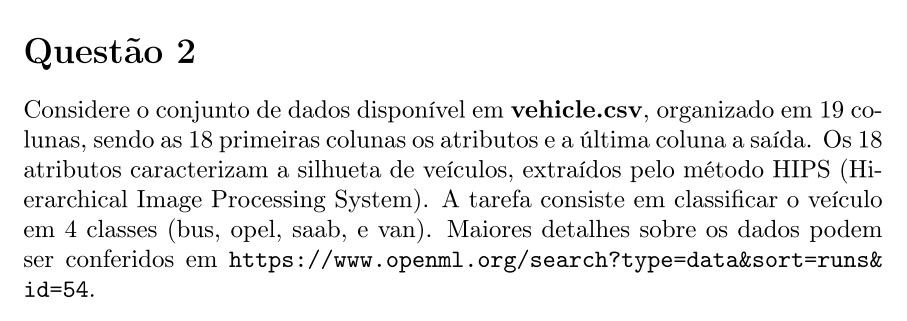

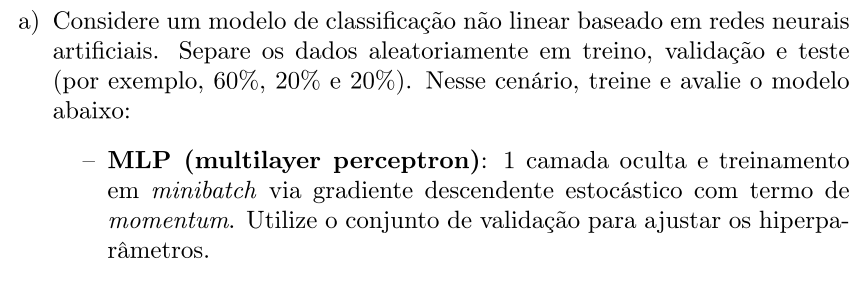

In [18]:
# 1. Carregar dados
df_vehicle = pd.read_csv('/content/vehicle.csv', header=None)
X_v = df_vehicle.iloc[:, :18].values
y_v_raw = df_vehicle.iloc[:, 18].values

# Convertendo rótulos categóricos em One-Hot Encoding via Pandas
y_v_encoded = pd.get_dummies(y_v_raw).values

In [19]:
# 2. Divisão 60% Treino, 20% Validação, 20% Teste
X_train_v, X_temp_v, y_train_v, y_temp_v = train_test_split(X_v, y_v_encoded, test_size=0.4, random_state=42)
X_val_v, X_test_v, y_val_v, y_test_v = train_test_split(X_temp_v, y_temp_v, test_size=0.5, random_state=42)

In [20]:
# 3. Normalização usando dados de Treino
scaler_v = StandardScaler()
X_train_v = scaler_v.fit_transform(X_train_v).T
X_val_v = scaler_v.transform(X_val_v).T
X_test_v = scaler_v.transform(X_test_v).T

y_train_v = y_train_v.T
y_val_v = y_val_v.T
y_test_v = y_test_v.T

In [24]:
# 4. Inicializar modelo e Treinar
mlp_vehicle = MLPNetwork(input_dim=18, hidden_dim=25, output_dim=4, activation='sigmoid', task='classification')
train_loss_v, val_loss_v = train_mlp(mlp_vehicle, X_train_v, y_train_v, X_val_v, y_val_v,
                                     epochs=400, batch_size=16, eta=0.02, beta=0.9)

# **Justificativa dos parâmetros (neurônios) das camadas**

1. Input: 18 neurônios. Motivo -> o dataset possui 18 colunas que correspondem as características.

2. Hidden: 25 neurônios. Essa camada, não possui uma fórmula para definir o número de neurônios correto, porém, utilizando o princípio: **não ultrapassar o dobro de neurônios da camada de entrada (input)**, e observando os resultados demonstrados na matriz de confusão, foi definido em 25.

3. Output: 4 neurônio. A questão apresenta um problema de classificação multiclasse. E sua solução pode ter 4 rótulos possíveis.

## Referências

<a>https://stats.stackexchange.com/questions/181/how-to-choose-the-number-of-hidden-layers-and-nodes-in-a-feedforward-neural-netw</a>

<a>https://iaexpert.academy/2020/05/04/quantas-camadas-escondidas-e-quantos-neuronios-incluir-numa-rede-neural-artificial/</a>

<a>https://www.fccdecastro.com.br/pdf/RNA_C4.pdf</a>

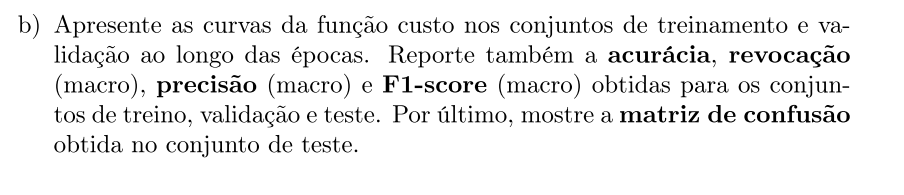

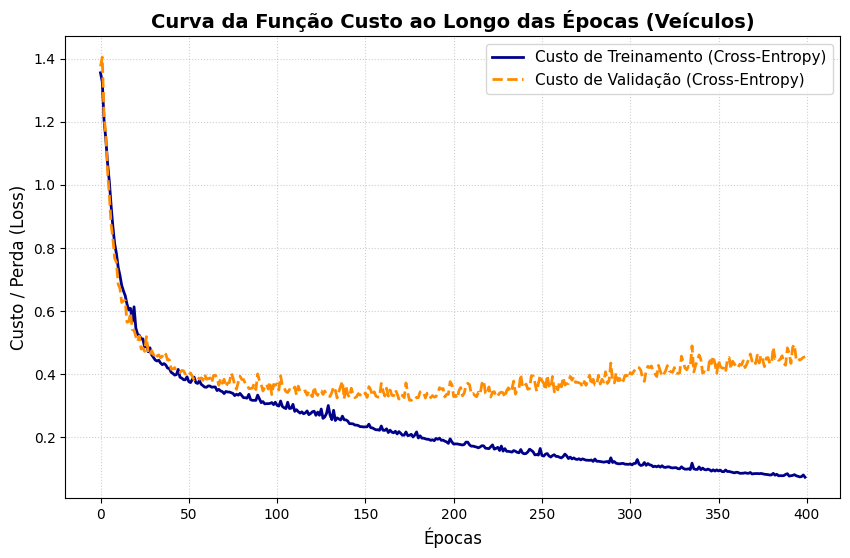

In [25]:
plt.figure(figsize=(10, 6))

# Plotagem das linhas de custo de treinamento e validação
plt.plot(train_loss_v, label='Custo de Treinamento (Cross-Entropy)', color='darkblue', linewidth=2)
plt.plot(val_loss_v, label='Custo de Validação (Cross-Entropy)', color='darkorange', linestyle='--', linewidth=2)

plt.title('Curva da Função Custo ao Longo das Épocas (Veículos)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Custo / Perda (Loss)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.show()


--- Métricas de Desempenho Veículos ---

Conjunto de Treinamento:
  Acurácia: 0.9941
  Precisão (macro): 0.9944
  Revocação (macro): 0.9941
  F1-Score (macro): 0.9942

Conjunto de Validação:
  Acurácia: 0.8343
  Precisão (macro): 0.8205
  Revocação (macro): 0.8112
  F1-Score (macro): 0.8055

Conjunto de Teste:
  Acurácia: 0.8765
  Precisão (macro): 0.8790
  Revocação (macro): 0.8823
  F1-Score (macro): 0.8801

--- Matriz de Confusão Conjunto de Teste ---


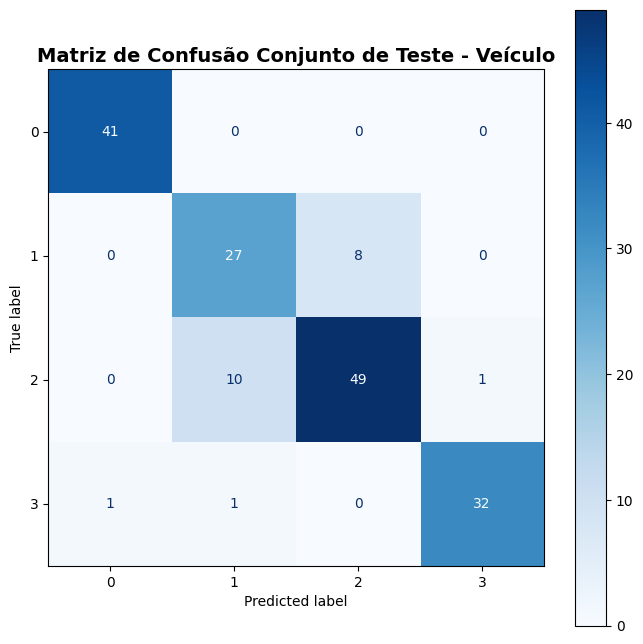

In [26]:
y_train_pred_v_proba = mlp_vehicle.forward(X_train_v)
y_val_pred_v_proba = mlp_vehicle.forward(X_val_v)
y_test_pred_v_proba = mlp_vehicle.forward(X_test_v)

y_train_true_classes = np.argmax(y_train_v, axis=0)
y_train_pred_classes = np.argmax(y_train_pred_v_proba, axis=0)

y_val_true_classes = np.argmax(y_val_v, axis=0)
y_val_pred_classes = np.argmax(y_val_pred_v_proba, axis=0)

y_test_true_classes = np.argmax(y_test_v, axis=0)
y_test_pred_classes = np.argmax(y_test_pred_v_proba, axis=0)

print("\n--- Métricas de Desempenho Veículos ---")

# Métricas Treino
print("\nConjunto de Treinamento:")
print(f"  Acurácia: {accuracy_score(y_train_true_classes, y_train_pred_classes):.4f}")
print(f"  Precisão (macro): {precision_score(y_train_true_classes, y_train_pred_classes, average='macro', zero_division=0):.4f}")
print(f"  Revocação (macro): {recall_score(y_train_true_classes, y_train_pred_classes, average='macro', zero_division=0):.4f}")
print(f"  F1-Score (macro): {f1_score(y_train_true_classes, y_train_pred_classes, average='macro', zero_division=0):.4f}")

# Métricas Validação
print("\nConjunto de Validação:")
print(f"  Acurácia: {accuracy_score(y_val_true_classes, y_val_pred_classes):.4f}")
print(f"  Precisão (macro): {precision_score(y_val_true_classes, y_val_pred_classes, average='macro', zero_division=0):.4f}")
print(f"  Revocação (macro): {recall_score(y_val_true_classes, y_val_pred_classes, average='macro', zero_division=0):.4f}")
print(f"  F1-Score (macro): {f1_score(y_val_true_classes, y_val_pred_classes, average='macro', zero_division=0):.4f}")

# Métricas Teste
print("\nConjunto de Teste:")
print(f"  Acurácia: {accuracy_score(y_test_true_classes, y_test_pred_classes):.4f}")
print(f"  Precisão (macro): {precision_score(y_test_true_classes, y_test_pred_classes, average='macro', zero_division=0):.4f}")
print(f"  Revocação (macro): {recall_score(y_test_true_classes, y_test_pred_classes, average='macro', zero_division=0):.4f}")
print(f"  F1-Score (macro): {f1_score(y_test_true_classes, y_test_pred_classes, average='macro', zero_division=0):.4f}")

# Matriz de confusão para conjunto de testes
print("\n--- Matriz de Confusão Conjunto de Teste ---")
cm = confusion_matrix(y_test_true_classes, y_test_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test_true_classes))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusão Conjunto de Teste - Veículo', fontsize=14, fontweight='bold')
plt.show()